In [2]:
#Import necessary libraries for data analysis and visualization
#pandas : for data manipualation and analysis 
#matplotlib : for creating visualization
# numpy : for numerical operations
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
#load the height-weight dataset from a CSV file
df = pd.read_csv('height-weight.csv')

In [4]:
# Display the first 5 rows of the dataset to inspect its structure 
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

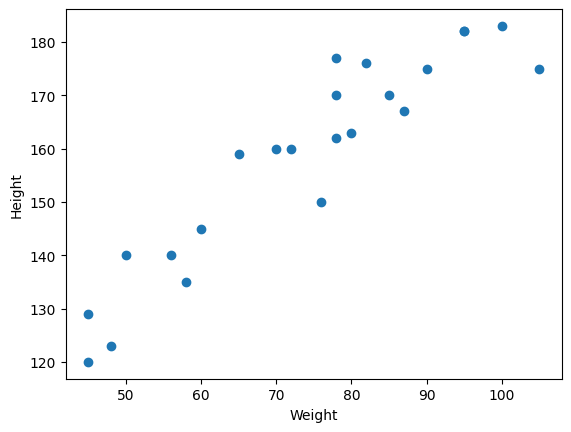

In [5]:
# create a scatter plot to visualize the relationship between Weight and HEight 
# This helps is see if there's a linear relationship betweem these variables 
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [6]:
# Calculate the correlation matrix between the variables
# This shows how strongly variables are related to eaach other (Values from -1 to 1)
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


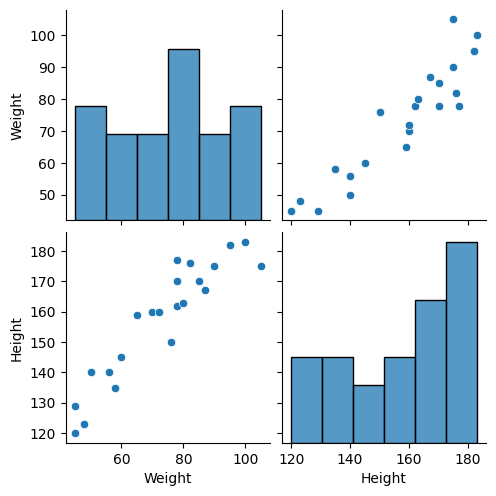

In [7]:
# Create a  more advanced visualization using seaborn
# pairplot shows distributionn and relationship between all variables in the dataset
import seaborn as sns
sns.pairplot(df)

In [11]:
# Define the independent (X) and dependent  (y) variables for our regression model
# X needs  to be a 2D arrary/dataframe (hence the double brackets)
# y can be a 1D array/series
X= df[['Weight']] #Independent variable(predictor)
y=df['Height']    # Dependent variable (what we want to predict)

In [12]:
# Create a series (1D) from the Weight column and check its shape 
# This demonstrates the difference between a Series and DataFrame 
X_series = df['Weight']
np.array(X_series).shape #will show (n,) where n is the number of samples

(23,)

In [13]:
# check the shape of  our target variable (y)
# This confirms its a 1D array with the same number of samples
np.array(y).shape

(23,)

In [14]:
# Import the function needed to split our data into training and testing sets
# This is important for evaluating model performance on unseen daa
from sklearn.model_selection import train_test_split

In [16]:
# Split the data into training (75%) and testing (25%) sets
# random_state = 42 ensures reproducible results(same split every time)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [17]:
# Import StandardScaler to normalize/standardize our data
# This helps models perform better by scaling all features to similar ranges
from sklearn.preprocessing import StandardScaler

In [19]:
# Create a StandardScaler object and apply it to the training data
# fit_transform() learns the scaling parameters and applies them in one step
# This transforms the data to have mean=0 and variance =1 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [20]:
# Apply the same scaling to the test data
# Important : We use transform() not fit_transform() to apply the same scaling as training data
# This prevents data leakage from the test set
X_test = scaler.transform(X_test)

In [21]:
# display the standardize test data
# Note that values are now centered around 0 with a standard deviationn of 1
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [23]:
# Import the Linear Regresssion model from scikit-Learn
# This is the main algorithm we'll use to build our predictive model
from sklearn.linear_model import LinearRegression

In [24]:
# Create a Linear Regression model instance
# n_jobs = -1 uses all variable CPU cores for faster computationon on large datasets
regression = LinearRegression(n_jobs=-1)

In [25]:
# Train (fit) the model using our training data
# This finds the optimal coefficients for the linear equation
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [26]:
# Display the model's learned parameters
# Coefficient (slope) : the change in Height for a one-unit change in Weight
# Intercept : the predicted Height when Weight is zero (or average Weight when standardized)
print("Coefficent or slope :",regression.coef_)
print("Intercept :",regression.intercept_)

Coefficent or slope : [17.2982057]
Intercept : 156.47058823529412


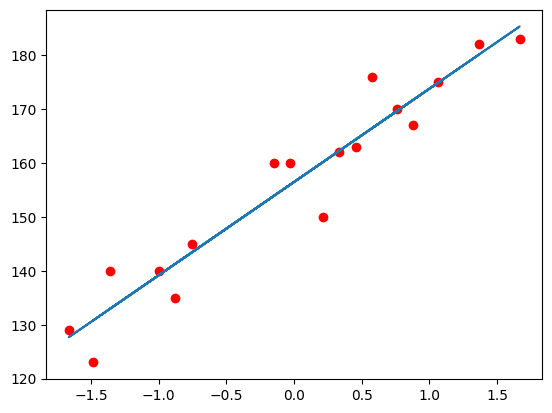

In [27]:
# Visualize the regression line along with the training data points
# The scatter points show actual data, while the line shows model predictions
# A good fit will have the line passing close to most points
plt.scatter(X_train,y_train,c="red")
plt.plot(X_train,regression.predict(X_train))

Prediction of test data

1.predicted height output = intercept + coef_(weights)


2.y_pred_test = 156.470 + 17.29(X_test)

In [28]:
# Make predictions on the test data
# This applies our trained model to new, unseen data points
y_pred = regression.predict(X_test)

In [29]:
# Import metrics to evaluate our model's performance
# These help us quantify how well our predictions match the actual values 
from sklearn.metrics import mean_absolute_error , mean_squared_error

In [30]:
# Calculate different error metrics to evaluate model performance:
# MSE (Mean Squared Error): Average of squared differences (sensitive to outlierrs)
# MAE (Mean Absolute Error): Average of absolute differences(more robust)
# RMSE (Root Mean Squared Error): Square rppt of  MSE (in same units as target)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


R Square  

Formula

R^2 = 1 - (SSR/SST)

R^2 = coefficient of determination SSR = sum of squares of residuals SST =total sum od squares

In [32]:
# Import R^2 (R-sqaured) score metric 
# R^2 measures the proportion of variance in the dependent variable explained by the model
from sklearn.metrics import r2_score

In [33]:
# calculate and display the R2 score 
# R2 ranges from 0 to 1 , where:
# -1 indicates perfect prediction
# - 0 indicates the model doesnt explain any variance (no better than the mean)
score = r2_score(y_test,y_pred)
print(score)

0.7360826717981276


Adjusted R2 = 1- [(1-r2)*(n-1)/(n-k-1)]

where:

R2 : The R2 of the model 

n: The number of observations 

k: The number of predictor variables

In [34]:
# calculate the adjusted R-squared
# This penalizes adding unnecessary predictors to the model 
# Adjusted R2 is more reliable than R2 when comparing models with different numbers of predictors
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

In [35]:
# Import statsmodels for more detailed statistical analysis 
# This library provides additional statistical details beyond scikit-learn
import statsmodels.api as sm


In [36]:
# Create and train an Ordinary Least Squares (OLS) regression model
# OLs is the traditional method used in Linear Regression
# Note : Statsmodels doesn't automatically add an intercept , but our data is standardized
model = sm.OLS(y_train,X_train).fit()

In [37]:
# Make predictions using the statsmodels OLS model
# compare these with the scikit -learn model predictions to verify consistency
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [38]:
# Display a comprehensive statistical summary of the OLS model
# This shows important details like :
# - Coefficients p-values (statistical significance)
# - Standard errors
# - R-squared  and Adjusted R -Squared
# - F-statistic (overall model significance )
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 05 Oct 2025   Prob (F-statistic):                       0.664
Time:                        10:01:59   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\Manamnath tiwari\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [39]:
# Use our trained model to predict the height for a new weight value (72)
# First transform the new data point using the same scaler used on training data
# This demonstrates how to use the model for real predictions on new data
regression.predict(scaler.transform([[72]]))

c:\Users\Manamnath tiwari\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])

When to use Simple linear regression

1. You want to see how one thing affects another.

Example: Does the number of hours you study affect your exam score?

2. There are only two variables involved.

-One is the cause (independent variable → hours studied).
-One is the effect (dependent variable → exam score).
3. You expect a straight-line relationship.

-If you put the data on a graph, the points roughly form a line (not a curve).
✅ Good examples where it makes sense:

-Predicting height from age (for kids).
-Predicting car fuel use from distance traveled.
-Predicting house price from its size.
❌ Not good to use if:

-The relationship is curved or complicated.
-Many factors affect the outcome (then you’d use multiple regression instead).